
## PROBLEM 2 : TAYLOR SERIES OF AN INTEGRAL

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sici
from scipy.special import factorial


### Taylor Series Approximation of an Integral Function

Given function

$$
f(x) = \frac{1}{x} \int_{0}^{x} \frac{\sin t}{t} \, dt, \quad x \neq 0.
$$

We have to derive the Taylor series expansion of f(x) about x = 0.


### 1: Taylor Series of sin t

The Taylor series expansion of the sine function about t = 0 is

$$
\sin t = \sum_{k=0}^{\infty} (-1)^k \frac{t^{2k+1}}{(2k+1)!}
$$

This expansion is valid for all real values of t.

### 2: Taylor Series of $\dfrac{\sin t}{t}$

Dividing each term of the Taylor series of $\sin t$ by $t$, we obtain

$$
\frac{\sin t}{t} = \sum_{k=0}^{\infty} (-1)^k \frac{t^{2k+1-1}}{(2k+1)!}.
$$

This expression is defined at $t = 0$ because

$$
\lim_{t \to 0} \frac{\sin t}{t} = 1.
$$

### 3: Integration

We now integrate the series from $0$ to $x$:

$$
\int_0^x \frac{\sin t}{t} \, dt
= \sum_{k=0}^{\infty} (-1)^k
\int_0^x \frac{t^{2k}}{(2k+1)!} \, dt.
$$

Evaluating the integral term-by-term gives

$$
\int_0^x \frac{\sin t}{t} \, dt
= \sum_{k=0}^{\infty}
(-1)^k \frac{x^{2k+1}}{(2k+1)(2k+1)!}.
$$

###4: Final Taylor Series of $f(x)$

Dividing the previous expression by $x$, we obtain the Taylor series of the given function:

$$
f(x) = \frac{1}{x} \int_0^x \frac{\sin t}{t} \, dt
= \sum_{k=0}^{\infty}
(-1)^k \frac{x^{2k}}{(2k+1)(2k+1)!}.
$$

This is the final Taylor series expansion of $f(x)$ about $x = 0$.

We'll simply write the code for this series.







In [ ]:
def f_taylor_scipy(x, n_terms):
    s = 0.0
    for k in range(n_terms):
        s += (-1)**k * x**(2*k) / ((2*k + 1) * factorial(2*k + 1, exact=True))
    return s


### Error Analysis

The Taylor series of the function is:

$$
f(x) = \sum_{k=0}^{\infty} (-1)^k \frac{x^{2k}}{(2k+1)(2k+1)!}.
$$

The remainder term after truncating $n$ terms is bounded by the **n+1  th term**:

$$
|R_n(x)| \le \frac{|x|^{2(n+1)}}{(2(n+1)+1)(2(n+1)+1)!}.
$$

On the interval $|x| < 1$, the **worst-case error** occurs at $x=1$. Therefore, to ensure the error is below $5 \times 10^{-9}$, we need:

$$
\frac{1^{2(n+1)}}{(2(n+1)+1)(2(n+1)+1)!} \le 5 \times 10^{-9}.
$$

We then choose the **smallest $n$** that satisfies this inequality.
For that value of n , we will run a loop from 0 to n and break the loop whenver the error goes above the given bound error.


In [ ]:
from math import factorial

target_error = 5e-9

# Start from n=0
n = 0

while True:
    # Compute the remainder bound at x=1 (worst case in |x|<1)
    remainder = 1**(2*(n+1)) / ((2*(n+1)+1) * factorial(2*(n+1)+1))

    if remainder <= target_error:
        break
    n += 1

print("Minimum number of terms required:", n+1)  # because we start from n = 0


Minimum number of terms required: 5


In [ ]:
def f_exact(x):
    Si, _ = sici(x)  # Only need sine integral Si(x)
    return np.where(x==0, 1.0, Si / x)


In [ ]:
def f_taylor_auto(x, n_terms=5):
    s = 0.0
    for k in range(n_terms):
        s += (-1)**k * x**(2*k) / ((2*k + 1) * factorial(2*k + 1))
    return s



In [ ]:

x_vals = np.linspace(-1, 1, 1000)
f_vals_taylor = np.array([f_taylor_auto(x, 5) for x in x_vals])
f_vals_exact = f_exact(x_vals)


In [ ]:
error = np.abs(f_vals_exact - f_vals_taylor)
print("Maximum absolute error:", error.max())


Maximum absolute error: 2.2651620579239307e-09


### Error Analysis(2)

The absolute error of the Taylor series approximation is defined as:

$$
\text{Error}(x) = \left| f_{\text{exact}}(x) - f_{\text{Taylor}}(x) \right|
$$

where

$$
f_{\text{exact}}(x) = \frac{1}{x} \int_0^x \frac{\sin t}{t} dt \quad \text{(computed using SciPy's sine integral)}
$$

and

$$
f_{\text{Taylor}}(x) = \sum_{k=0}^{4} (-1)^k \frac{x^{2k}}{(2k+1)(2k+1)!}.
$$

  

From the plot, we see that

$$
\text{Error}(x) \le 5 \times 10^{-9} \quad \forall \, |x| < 1,
$$

confirming that our **5-term Taylor series approximation satisfies the prescribed error bound**.


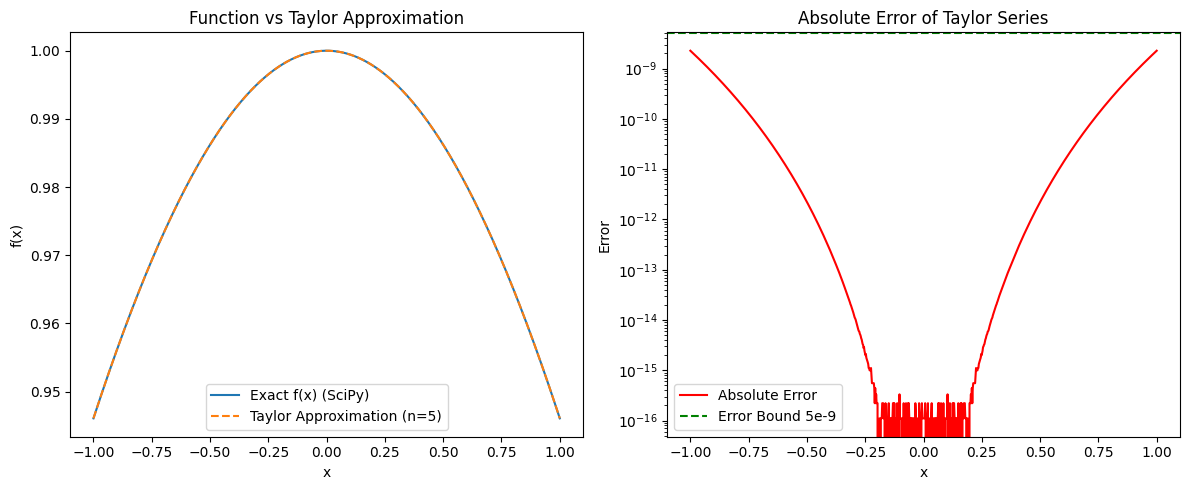

In [ ]:
plt.figure(figsize=(12,5))

# Function comparison
plt.subplot(1,2,1)
plt.plot(x_vals, f_vals_exact, label='Exact f(x) (SciPy)')
plt.plot(x_vals, f_vals_taylor, '--', label='Taylor Approximation (n=5)')
plt.title('Function vs Taylor Approximation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Error plot
plt.subplot(1,2,2)
plt.plot(x_vals, error, color='red', label='Absolute Error')
plt.yscale('log')
plt.axhline(5e-9, color='green', linestyle='--', label='Error Bound 5e-9')
plt.title('Absolute Error of Taylor Series')
plt.xlabel('x')
plt.ylabel('Error')
plt.legend()

plt.tight_layout()
plt.show()


### Conclusion

 We approximated the function defined by an integral using its Taylor series. Since the Taylor series is infinite, we had to truncate it after a few terms to make calculations practical. To ensure that our approximation was accurate, we used the remainder term to estimate the error and determined that using 5 terms was enough to keep the error extremely small, below the target of
5
×
10
−
9


We then compared our truncated Taylor series with the exact function calculated using SciPy and plotted the absolute error across the interval
[−1,1]. The plot confirmed that the error never exceeded the prescribed limit, showing that the Taylor series approximation is both reliable and highly accurate.

